In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, log_loss, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_transformer

In [97]:
df = pd.read_csv('../data/train.csv')

In [98]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [100]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Извлекаем статус из имени

In [101]:
title_map = {
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
    'Countess': 'Rare', 'Lady': 'Rare', 'Sir': 'Rare', 'Don': 'Rare', 'Jonkheer': 'Rare',
    'Capt': 'Rare', 'Major': 'Rare', 'Col': 'Rare', 'Dr': 'Rare', 'Rev': 'Rare'
}
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df['Title'] = df['Title'].replace(title_map)
df['Title'] = df['Title'].where(df['Title'].isin(['Mr','Mrs','Miss','Master','Rare']), 'Rare')
df.Title.value_counts()

rank_map = {
    'Mr': 1, 'Miss': 2, 'Mrs': 3, 'Master': 4,
    'Dr': 5, 'Rev': 5, 'Col': 5, 'Major': 5, 'Capt': 5, 
    'Sir': 5, 'Lady': 5, 'Countess': 5, 'Don': 5, 
    'Jonkheer': 5, 'Ms': 5, 'Mlle': 5, 'Mme': 5
}
df['Social_Rank'] = df['Title'].map(rank_map).fillna(5).astype(int)

### Добавляем признак наличия членов семьи на борту

In [102]:
df['HasFamily'] = df['SibSp'] + df['Parch']
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Social_Rank,HasFamily
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,1,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,3,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,2,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,3,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Rare,5,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss,2,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Miss,2,3
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Mr,1,0


In [103]:
imp_feats = df.drop(['Survived'], axis=1)
target = df['Survived']

In [104]:
target.value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

### Посмотрим на графики для разных признаков

Text(0.5, 0, 'Survived')

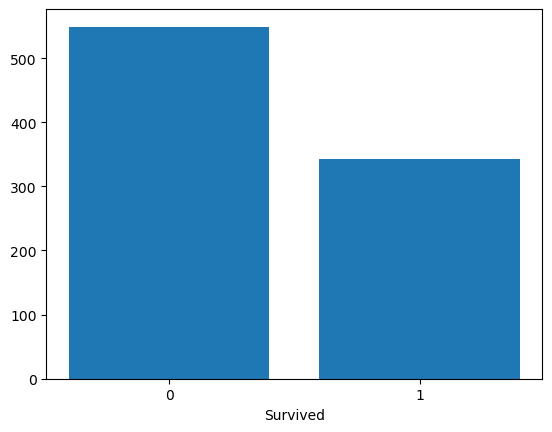

In [105]:
plt.bar(df['Survived'].unique(), df['Survived'].value_counts(), tick_label = ['0', '1'])
plt.xlabel('Survived')

In [106]:
port = df['Embarked'].fillna('Unknown')

Text(0.5, 0, 'Embarked')

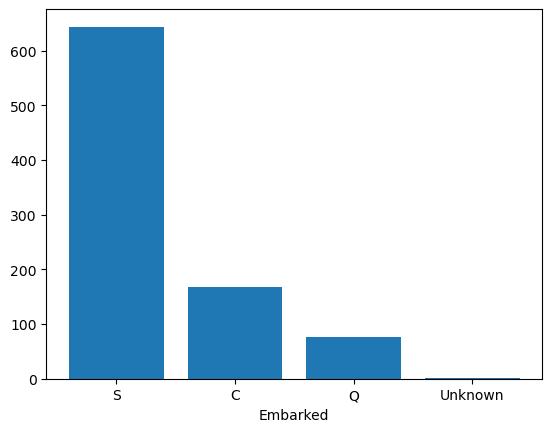

In [107]:
plt.bar(port.unique(), port.value_counts(), tick_label = ['S', 'C', 'Q', 'Unknown'])
plt.xlabel('Embarked')

<Axes: xlabel='Pclass', ylabel='count'>

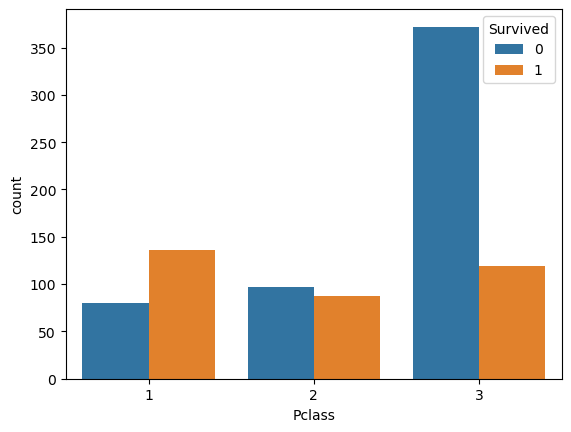

In [108]:
sns.countplot(x = 'Pclass', hue = 'Survived', data = df)

### В 3 классе больше всего погибших, в 1 больше всего выживших

<Axes: xlabel='Sex', ylabel='count'>

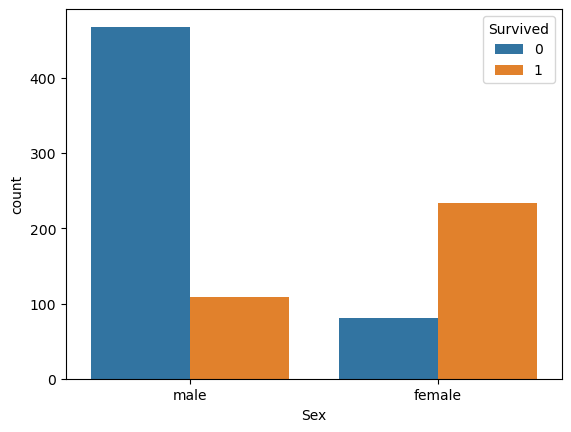

In [109]:
sns.countplot(x = 'Sex', hue = 'Survived', data = df)

### Смотрим числовые признаки

Нормальное распределение только у Age

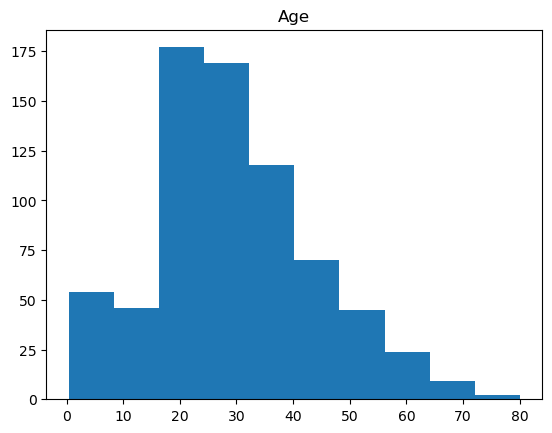

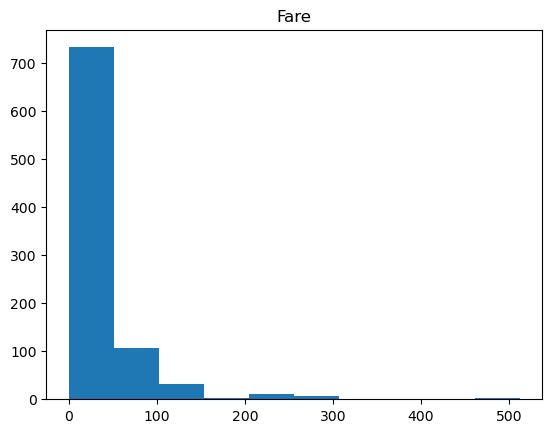

In [110]:
df_num = df[['Age', 'Fare']]

for i in df_num.columns:
    plt.hist(df_num[i])
    plt.title(i)
    plt.show()

### Смотрим корреляцию

<Axes: >

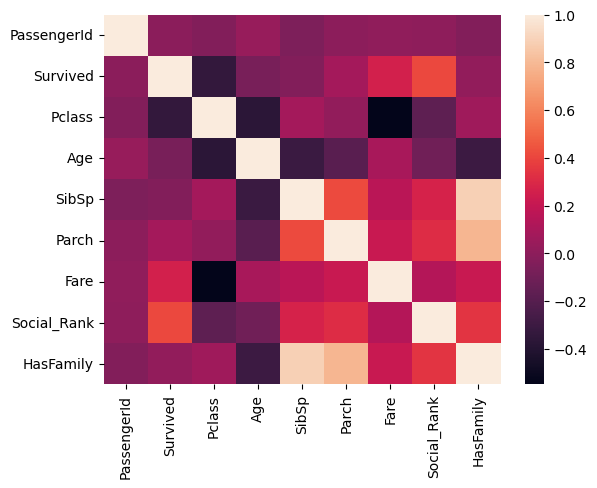

In [111]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr)

Хорошая корреляция у (SibSp, Parch), (Fare, Survived)

In [112]:
pd.pivot_table(df, index = 'Survived', values = ['Age','SibSp','Parch','Fare'])

,Age,Fare,Parch,SibSp
Survived,,,,
0,30.626179,22.117887,0.329690,0.553734
1,28.343690,48.395408,0.464912,0.473684


### Подготовка к обучению

In [113]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Social_Rank,HasFamily
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,1,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,3,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,2,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,3,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Rare,5,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss,2,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Miss,2,3
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Mr,1,0


In [114]:
df_clean = df.drop(['SibSp', 'Parch', 'Ticket'], axis=1)
df_clean

,PassengerId,Survived,Pclass,Name,Sex,Age,Fare,Cabin,Embarked,Title,Social_Rank,HasFamily
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,NaN,S,Mr,1,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,C85,C,Mrs,3,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250,NaN,S,Miss,2,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,C123,S,Mrs,3,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,8.0500,NaN,S,Mr,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,13.0000,NaN,S,Rare,5,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,30.0000,B42,S,Miss,2,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,23.4500,NaN,S,Miss,2,3
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,30.0000,C148,C,Mr,1,0


### Выбираем нужные признаки

In [115]:
imp_feats = df_clean.drop(['Survived', 'PassengerId', 'Cabin', 'Name'], axis=1).copy()
target = df['Survived']

imp_feats

,Pclass,Sex,Age,Fare,Embarked,Title,Social_Rank,HasFamily
0,3,male,22.0,7.2500,S,Mr,1,1
1,1,female,38.0,71.2833,C,Mrs,3,1
2,3,female,26.0,7.9250,S,Miss,2,0
3,1,female,35.0,53.1000,S,Mrs,3,1
4,3,male,35.0,8.0500,S,Mr,1,0
...,...,...,...,...,...,...,...,...
886,2,male,27.0,13.0000,S,Rare,5,0
887,1,female,19.0,30.0000,S,Miss,2,0
888,3,female,NaN,23.4500,S,Miss,2,3
889,1,male,26.0,30.0000,C,Mr,1,0


In [116]:
X_train, X_test, y_train, y_test = train_test_split(imp_feats, target, stratify=target, test_size= 0.2, random_state=21)

In [117]:
num_feats = ['Age', 'HasFamily', 'Social_Rank', 'Fare']
cat_feats = ['Pclass', 'Sex', 'Embarked']

### Собираем Pipeline

In [118]:
num_prep = make_pipeline(SimpleImputer(strategy='median'), StandardScaler())
cat_prep = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore', sparse_output=False)
)

preprocessor = make_column_transformer((num_prep, num_feats), (cat_prep, cat_feats))

In [119]:
models = {
    'Dummy': DummyClassifier(random_state=21, strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(random_state=21),
    'Decision Tree': DecisionTreeClassifier(random_state=21),
    'SVM': SVC(probability=True, random_state=21),
    'KNN': KNeighborsClassifier(n_neighbors=8),
    'Random Forest': RandomForestClassifier(random_state=21)
}

In [120]:
test_score = pd.DataFrame(columns=['model', 'accuracy', 'neg_log_loss', 'precision', 'recall', 'roc_auc'])
train_score = pd.DataFrame(columns=test_score.columns)

### Обучаем baseline

In [121]:
strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=21)

In [122]:
for name, model in models.items():
    base_pipe = make_pipeline(
        preprocessor, 
        model
    )

    #кросс-валидация ценит абсолютное значение, а так как хорошая logloss стремится к нулю, берем её со знаком "1", чтобы модель правильно работала
    cv_res = cross_validate(base_pipe, X_train, y_train, scoring=list(test_score.columns[1:]), cv=strat_kfold, n_jobs=-1, return_train_score=True)
    
    mean_accuracy_test  = cv_res['test_accuracy'].mean()
    mean_logloss_test   = -cv_res['test_neg_log_loss'].mean()  # умножаем на -1, чтобы убрать минус
    mean_precision_test = cv_res['test_precision'].mean()
    mean_recall_test    = cv_res['test_recall'].mean()
    mean_roc_auc_test   = cv_res['test_roc_auc'].mean()

    mean_accuracy_train  = cv_res['train_accuracy'].mean()
    mean_logloss_train   = -cv_res['train_neg_log_loss'].mean()  # умножаем на -1, чтобы убрать минус
    mean_precision_train = cv_res['train_precision'].mean()
    mean_recall_train    = cv_res['train_recall'].mean()
    mean_roc_auc_train   = cv_res['train_roc_auc'].mean()

    test_score.loc[len(test_score)] = [
        name, 
        mean_accuracy_test, 
        mean_logloss_test, 
        mean_precision_test, 
        mean_recall_test, 
        mean_roc_auc_test
    ]

    train_score.loc[len(train_score)] = [
            name, 
            mean_accuracy_train, 
            mean_logloss_train, 
            mean_precision_train, 
            mean_recall_train, 
            mean_roc_auc_train
        ]

In [123]:
train_score.sort_values(by='roc_auc', ascending=False)

,model,accuracy,neg_log_loss,precision,recall,roc_auc
2,Decision Tree,0.986305,0.022740,0.993445,0.970705,0.999527
5,Random Forest,0.986305,0.113959,0.988871,0.975284,0.998575
4,KNN,0.850069,0.327916,0.863777,0.723451,0.921350
3,SVM,0.844804,0.398696,0.831217,0.747254,0.893569
1,Logistic Regression,0.814605,0.423889,0.774811,0.728026,0.867442
0,Dummy,0.616573,13.820101,0.000000,0.000000,0.500000


### Видим, что `Random Forest` и `Decision Tree` экстремально сильно переобучены, неутешительные результаты показывает также `KNN`

In [124]:
df_val = test_score.set_index('model')
df_train = train_score.set_index('model')

df_val['neg_log_loss'] = df_val['neg_log_loss'].abs()
df_train['neg_log_loss'] = df_train['neg_log_loss'].abs()

df_val = df_val.rename(columns={'neg_log_loss': 'log_loss'})
df_train = df_train.rename(columns={'neg_log_loss': 'log_loss'})

pct_diff = ((df_val - df_train) / df_train) * 100
pct_diff_sorted = pct_diff.sort_values(by='roc_auc', ascending=False)

pct_diff_sorted = pct_diff_sorted.round(2).astype(str) + '%'
pct_diff_sorted.loc['Dummy', ['precision', 'recall']] = '0.0%'

pct_diff_sorted

,accuracy,log_loss,precision,recall,roc_auc
model,,,,,
Dummy,0.0%,-0.0%,0.0%,0.0%,0.0%
Logistic Regression,-0.68%,3.44%,-0.6%,-1.38%,-0.85%
SVM,-1.41%,8.26%,-1.0%,-2.96%,-3.88%
KNN,-3.84%,323.81%,-4.3%,-6.87%,-5.87%
Random Forest,-19.83%,634.35%,-24.86%,-28.67%,-14.18%
Decision Tree,-22.53%,36494.42%,-30.8%,-26.83%,-24.85%


### Также посмотрим на то, как сильно будут отличаться метрики для моделей, если обучить их на **неотмасштабированных** данных

In [125]:
test_score_not_scaled = pd.DataFrame(columns=test_score.columns)
train_score_not_scaled = pd.DataFrame(columns=test_score.columns)

In [126]:
for name, model in models.items():
    base_pipe = make_pipeline(
        make_column_transformer((make_pipeline(SimpleImputer(strategy='median')), num_feats), (cat_prep, cat_feats)), 
        model
    )
    
    cv_res = cross_validate(base_pipe, X_train, y_train, scoring=list(test_score_not_scaled.columns[1:]), cv=strat_kfold, n_jobs=-1, return_train_score=True)
    
    mean_accuracy_test  = cv_res['test_accuracy'].mean()
    mean_logloss_test   = -cv_res['test_neg_log_loss'].mean()  # умножаем на -1, чтобы убрать минус
    mean_precision_test = cv_res['test_precision'].mean()
    mean_recall_test    = cv_res['test_recall'].mean()
    mean_roc_auc_test   = cv_res['test_roc_auc'].mean()

    mean_accuracy_train  = cv_res['train_accuracy'].mean()
    mean_logloss_train   = -cv_res['train_neg_log_loss'].mean()  # умножаем на -1, чтобы убрать минус
    mean_precision_train = cv_res['train_precision'].mean()
    mean_recall_train    = cv_res['train_recall'].mean()
    mean_roc_auc_train   = cv_res['train_roc_auc'].mean()

    test_score_not_scaled.loc[len(test_score_not_scaled)] = [
        f'{name}_not_scaled', 
        mean_accuracy_test, 
        mean_logloss_test, 
        mean_precision_test, 
        mean_recall_test, 
        mean_roc_auc_test
    ]

    train_score_not_scaled.loc[len(train_score_not_scaled)] = [
            f'{name}_not_scaled', 
            mean_accuracy_train, 
            mean_logloss_train, 
            mean_precision_train, 
            mean_recall_train, 
            mean_roc_auc_train
        ]

### На тестовой выборке все "отмасштабированные" модели показали лучшие результаты

In [127]:
test_score_not_scaled.sort_values(by='roc_auc', ascending=False, ignore_index=True)

,model,accuracy,neg_log_loss,precision,recall,roc_auc
0,Logistic Regression_not_scaled,0.813247,0.438550,0.779824,0.717980,0.860019
1,Random Forest_not_scaled,0.792121,0.837354,0.742243,0.702963,0.857141
2,SVM_not_scaled,0.681089,0.604840,0.692115,0.311111,0.771164
3,KNN_not_scaled,0.714804,1.508497,0.669460,0.505185,0.756369
4,Decision Tree_not_scaled,0.766847,8.221127,0.691433,0.713872,0.753833
5,Dummy_not_scaled,0.616576,13.819988,0.000000,0.000000,0.500000


### На обучающей выборке все "отмасштабированные" модели также показали лучшие результаты

In [128]:
train_score_not_scaled.sort_values(by='roc_auc', ascending=False, ignore_index=True)

,model,accuracy,neg_log_loss,precision,recall,roc_auc
0,Decision Tree_not_scaled,0.986305,0.022740,0.993445,0.970705,0.999527
1,Random Forest_not_scaled,0.986305,0.113985,0.988871,0.975284,0.998590
2,Logistic Regression_not_scaled,0.814605,0.423899,0.774819,0.728030,0.867410
3,KNN_not_scaled,0.775627,0.455966,0.776160,0.584198,0.848371
4,SVM_not_scaled,0.692059,0.593219,0.722133,0.319530,0.777457
5,Dummy_not_scaled,0.616573,13.820101,0.000000,0.000000,0.500000


### И тут точно так же присутствует проблема переобученности `Random Forest` и `Decision Tree`

In [129]:
df_val_nsc = test_score_not_scaled.set_index('model')
df_train_nsc = train_score_not_scaled.set_index('model')

df_val_nsc['neg_log_loss'] = df_val_nsc['neg_log_loss'].abs()
df_train_nsc['neg_log_loss'] = df_train_nsc['neg_log_loss'].abs()

df_val_nsc = df_val_nsc.rename(columns={'neg_log_loss': 'log_loss'})
df_train_nsc = df_train_nsc.rename(columns={'neg_log_loss': 'log_loss'})

pct_diff_nsc = ((df_val_nsc - df_train_nsc) / df_train_nsc) * 100

pct_diff_nsc_sorted = pct_diff_nsc.sort_values(by='roc_auc', ascending=False)

pct_diff_styled_nsc = pct_diff_nsc_sorted.round(2).astype(str) + '%'
pct_diff_styled_nsc.loc['Dummy_not_scaled', ['precision', 'recall']] = '0.0%'

pct_diff_styled_nsc

,accuracy,log_loss,precision,recall,roc_auc
model,,,,,
Dummy_not_scaled,0.0%,-0.0%,0.0%,0.0%,0.0%
SVM_not_scaled,-1.59%,1.96%,-4.16%,-2.63%,-0.81%
Logistic Regression_not_scaled,-0.17%,3.46%,0.65%,-1.38%,-0.85%
KNN_not_scaled,-7.84%,230.84%,-13.75%,-13.53%,-10.84%
Random Forest_not_scaled,-19.69%,634.62%,-24.94%,-27.92%,-14.16%
Decision Tree_not_scaled,-22.25%,36052.82%,-30.4%,-26.46%,-24.58%


In [130]:
scal_diff_test = ((test_score.drop('model', axis=1) - test_score_not_scaled.drop('model', axis=1)) / test_score.drop('model', axis=1) * 100).sort_values('roc_auc', ascending=False)
scal_diff_test = pd.concat([test_score.model, scal_diff_test], axis=1).set_index('model').round(2).astype(str) + '%'
scal_diff_test.loc['Dummy', ['precision', 'recall']] = '0.0%'
scal_diff_test

,accuracy,neg_log_loss,precision,recall,roc_auc
model,,,,,
Dummy,0.0%,0.0%,0.0%,0.0%,0.0%
Logistic Regression,-0.52%,-0.02%,-1.26%,0.0%,0.01%
Decision Tree,-0.37%,1.21%,-0.57%,-0.5%,-0.36%
SVM,18.23%,-40.13%,15.89%,57.1%,10.21%
KNN,12.56%,-8.55%,19.01%,25.02%,12.78%
Random Forest,-0.18%,-0.06%,0.1%,-1.05%,-0.02%


In [131]:
scal_diff_train = ((train_score.drop('model', axis=1) - train_score_not_scaled.drop('model', axis=1)) / train_score.drop('model', axis=1) * 100).sort_values('roc_auc', ascending=False)
scal_diff_train = pd.concat([train_score.model, scal_diff_train], axis=1).set_index('model').round(2).astype(str) + '%'
scal_diff_train.loc['Dummy', ['precision', 'recall']] = '0.0%'
scal_diff_train

,accuracy,neg_log_loss,precision,recall,roc_auc
model,,,,,
Dummy,0.0%,0.0%,0.0%,0.0%,0.0%
Logistic Regression,-0.0%,-0.0%,-0.0%,-0.0%,0.0%
Decision Tree,0.0%,0.0%,0.0%,0.0%,0.0%
SVM,18.08%,-48.79%,13.12%,57.24%,12.99%
KNN,8.76%,-39.05%,10.14%,19.25%,7.92%
Random Forest,0.0%,-0.02%,0.0%,0.0%,-0.0%


## Промежуточный итог по метрикам моделей:

- Лучшая модель по `ROC-AUC` - `Random Forest`, но модель оказалась сильно переобученной, как и `KNN`
- Самая стабильная модель - `Logistic Regression` и `SVC`
- Лучшая модель по `accuracy` и `log_loss` - `SVC`
- Модель, меньше всего подверженная переобучению - `Logistic Regression`
- Масштабирование имеет критическое значение для моделей `SVC` и `KNN`

---

### **Следующий этап**: обучение моделей с подбором лучших гиперпараметров через GridSearch и RandomSearch

In [132]:
scikit_scoring = {
    'accuracy': 'accuracy',
    'logloss': 'neg_log_loss',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc'
}

In [133]:
grid_params = [
    {
        'model': [LogisticRegression(random_state=21)],
        'model__penalty': ['l1', 'l2'],
        'model__C': [0.01, 0.1, 1, 10],
        'model__solver': ['liblinear']
    },
    {
        'model': [SVC(probability=True, random_state=21)],
        'model__kernel': ['linear', 'rbf'],
        'model__C': [0.01, 0.1, 1, 10]
    },
    {
        'model': [KNeighborsClassifier()],
        'model__n_neighbors': [5, 8, 10],
        'model__metric': ['euclidean']
    }
]

rand_params = [
    {
        'model': [RandomForestClassifier(random_state=21)],
        'model__n_estimators': np.linspace(20, 200, 10, dtype=int),
        'model__max_depth': np.linspace(5, 100, 5, dtype=int),
        'model__min_samples_split': [2, 5]
    },
    {
        'model': [DecisionTreeClassifier(random_state=21)],
        'model__criterion': ['gini', 'entropy'],
        'model__max_depth': np.linspace(5, 100, 5, dtype=int),
        'model__min_samples_split': [2, 5]
    }
]

In [134]:
base_pipe = Pipeline([
    ('preprocess', preprocessor), 
    ('model', LogisticRegression(solver='liblinear'))
])

In [135]:
grid_search = GridSearchCV(base_pipe, grid_params, cv=strat_kfold, verbose=3, scoring=scikit_scoring, refit='roc_auc', n_jobs=-1)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 19 candidates, totalling 95 fits


,estimator,Pipeline(step...liblinear'))])
,param_grid,"[{'model': [LogisticRegre...ndom_state=21)], 'model__C': [0.01, 0.1, ...], 'model__penalty': ['l1', 'l2'], 'model__solver': ['liblinear']}, {'model': [SVC(probabili...ndom_state=21)], 'model__C': [0.01, 0.1, ...], 'model__kernel': ['linear', 'rbf']}, ...]"
,scoring,"{'accuracy': 'accuracy', 'logloss': 'neg_log_loss', 'precision': 'precision', 'recall': 'recall', ...}"
,n_jobs,-1
,refit,'roc_auc'
,cv,StratifiedKFo... shuffle=True)
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('pipeline-1', ...), ('pipeline-2', ...)]"


In [136]:
random_search = RandomizedSearchCV(
    base_pipe, rand_params, 
    n_iter=20, cv=strat_kfold, scoring=scikit_scoring, 
    refit='roc_auc', n_jobs=-1, random_state=21
)

random_search.fit(X_train, y_train)

,estimator,Pipeline(step...liblinear'))])
,param_distributions,"[{'model': [RandomForestC...ndom_state=21)], 'model__max_depth': array([ 5, ...52, 76, 100]), 'model__min_samples_split': [2, 5], 'model__n_estimators': array([ 20, ...60, 180, 200])}, {'model': [DecisionTreeC...ndom_state=21)], 'model__criterion': ['gini', 'entropy'], 'model__max_depth': array([ 5, ...52, 76, 100]), 'model__min_samples_split': [2, 5]}]"
,n_iter,20
,scoring,"{'accuracy': 'accuracy', 'logloss': 'neg_log_loss', 'precision': 'precision', 'recall': 'recall', ...}"
,n_jobs,-1
,refit,'roc_auc'
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,21
,error_score,nan


In [137]:
grid_res = pd.DataFrame(grid_search.cv_results_)
grid_res['model'] = grid_res['param_model'].apply(lambda x: x.__class__.__name__)

best_grid = grid_res.sort_values('rank_test_roc_auc').set_index('rank_test_roc_auc')
best_grid

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model,param_model__C,param_model__penalty,param_model__solver,param_model__kernel,param_model__metric,...,std_test_recall,rank_test_recall,split0_test_roc_auc,split1_test_roc_auc,split2_test_roc_auc,split3_test_roc_auc,split4_test_roc_auc,mean_test_roc_auc,std_test_roc_auc,model
rank_test_roc_auc,,,,,,,,,,,,,,,,,,,,,
1,0.013583,0.001689,0.043259,0.021157,KNeighborsClassifier(),NaN,NaN,NaN,NaN,euclidean,...,0.042407,14,0.887397,0.816219,0.842803,0.909617,0.886729,0.868553,0.033981,KNeighborsClassifier
2,0.017810,0.005070,0.027284,0.003787,KNeighborsClassifier(),NaN,NaN,NaN,NaN,euclidean,...,0.066494,15,0.898244,0.826240,0.845960,0.880997,0.886625,0.867613,0.027054,KNeighborsClassifier
3,0.020308,0.013427,0.028167,0.006028,KNeighborsClassifier(),NaN,NaN,NaN,NaN,euclidean,...,0.041005,17,0.902686,0.816839,0.834386,0.890993,0.891223,0.867225,0.034686,KNeighborsClassifier
4,0.015625,0.000851,0.037935,0.001627,LogisticRegression(random_state=21),0.10,l2,liblinear,NaN,NaN,...,0.021802,2,0.899587,0.842149,0.830703,0.869739,0.867189,0.861873,0.023971,LogisticRegression
5,0.015862,0.001205,0.038621,0.004920,LogisticRegression(random_state=21),1.00,l2,liblinear,NaN,NaN,...,0.046814,7,0.884917,0.843802,0.831334,0.869529,0.870951,0.860107,0.019574,LogisticRegression
6,0.023246,0.015804,0.052995,0.014695,LogisticRegression(random_state=21),10.00,l2,liblinear,NaN,NaN,...,0.046688,5,0.880785,0.844008,0.831755,0.870370,0.869697,0.859323,0.018357,LogisticRegression
7,0.017082,0.002844,0.050968,0.017804,LogisticRegression(random_state=21),10.00,l1,liblinear,NaN,NaN,...,0.046688,5,0.879752,0.844421,0.831545,0.870160,0.869906,0.859157,0.018113,LogisticRegression
8,0.017299,0.003723,0.039873,0.004821,LogisticRegression(random_state=21),0.10,l1,liblinear,NaN,NaN,...,0.019144,9,0.895661,0.839256,0.827125,0.859638,0.873041,0.858944,0.024279,LogisticRegression
9,0.014751,0.003605,0.035381,0.006638,LogisticRegression(random_state=21),1.00,l1,liblinear,NaN,NaN,...,0.038760,8,0.881405,0.844835,0.830703,0.867003,0.870533,0.858896,0.018441,LogisticRegression


In [138]:
roc_auc_splits = ['split0_test_roc_auc', 'split1_test_roc_auc', 'split2_test_roc_auc', 'split3_test_roc_auc', 'split4_test_roc_auc']
best_grid['mean_test_roc_auc'] = best_grid[roc_auc_splits].mean(axis=1)
best_grid['std_test_roc_auc'] = best_grid[roc_auc_splits].std(axis=1)
best_grid[['model', 'mean_test_roc_auc', 'std_test_roc_auc']].sort_values('mean_test_roc_auc', ascending=False)

,model,mean_test_roc_auc,std_test_roc_auc
rank_test_roc_auc,,,
1,KNeighborsClassifier,0.868553,0.037992
2,KNeighborsClassifier,0.867613,0.030247
3,KNeighborsClassifier,0.867225,0.038780
4,LogisticRegression,0.861873,0.026801
5,LogisticRegression,0.860107,0.021884
6,LogisticRegression,0.859323,0.020523
7,LogisticRegression,0.859157,0.020251
8,LogisticRegression,0.858944,0.027145
9,LogisticRegression,0.858896,0.020618


### **Лучшая модель по `GridSearch` - `SVC`**

In [139]:
rand_res = pd.DataFrame(random_search.cv_results_)
rand_res['model'] = rand_res['param_model'].apply(lambda x: x.__class__.__name__)
best_rand = rand_res.sort_values('rank_test_roc_auc').set_index('rank_test_roc_auc')
best_rand.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_estimators,param_model__min_samples_split,param_model__max_depth,param_model,param_model__criterion,params,...,std_test_recall,rank_test_recall,split0_test_roc_auc,split1_test_roc_auc,split2_test_roc_auc,split3_test_roc_auc,split4_test_roc_auc,mean_test_roc_auc,std_test_roc_auc,model
rank_test_roc_auc,,,,,,,,,,,,,,,,,,,,,
1,0.431561,0.110380,0.056667,0.018374,160.0,2,5,RandomForestClassifier(random_state=21),NaN,"{'model__n_estimators': 160, 'model__min_sampl...",...,0.031048,2,0.917355,0.845248,0.860585,0.879104,0.881609,0.876780,0.024214,RandomForestClassifier
2,0.164201,0.030257,0.024403,0.005868,80.0,5,5,RandomForestClassifier(random_state=21),NaN,"{'model__n_estimators': 80, 'model__min_sample...",...,0.035645,9,0.918182,0.851653,0.859743,0.873001,0.880773,0.876670,0.023091,RandomForestClassifier
3,0.606521,0.111407,0.064771,0.016566,200.0,5,5,RandomForestClassifier(random_state=21),NaN,"{'model__n_estimators': 200, 'model__min_sampl...",...,0.027233,9,0.918182,0.846178,0.856166,0.877841,0.880460,0.875765,0.024840,RandomForestClassifier
4,0.137984,0.021391,0.052523,0.008244,40.0,5,100,RandomForestClassifier(random_state=21),NaN,"{'model__n_estimators': 40, 'model__min_sample...",...,0.046765,11,0.907851,0.823450,0.845223,0.898464,0.892163,0.873430,0.033033,RandomForestClassifier
5,0.378620,0.043355,0.067842,0.010074,100.0,5,52,RandomForestClassifier(random_state=21),NaN,"{'model__n_estimators': 100, 'model__min_sampl...",...,0.050293,3,0.903926,0.830475,0.847327,0.892151,0.887983,0.872372,0.028331,RandomForestClassifier


In [140]:
roc_auc_splits = ['split0_test_roc_auc', 'split1_test_roc_auc', 'split2_test_roc_auc', 'split3_test_roc_auc', 'split4_test_roc_auc']
best_rand['mean_test_roc_auc'] = best_rand[roc_auc_splits].mean(axis=1)
best_rand['std_test_roc_auc'] = best_rand[roc_auc_splits].std(axis=1)

best_rand[['model', 'mean_test_roc_auc', 'std_test_roc_auc']].sort_values('mean_test_roc_auc', ascending=False)

,model,mean_test_roc_auc,std_test_roc_auc
rank_test_roc_auc,,,
1,RandomForestClassifier,0.876780,0.027072
2,RandomForestClassifier,0.876670,0.025816
3,RandomForestClassifier,0.875765,0.027772
4,RandomForestClassifier,0.873430,0.036932
5,RandomForestClassifier,0.872372,0.031675
6,RandomForestClassifier,0.870951,0.032628
7,RandomForestClassifier,0.870799,0.033496
8,RandomForestClassifier,0.870042,0.033806
9,RandomForestClassifier,0.869815,0.037604


### **Лучшая модель по `RandomSearch` - `RandomForestClassifier`**

## Лучший показатель среди моделей с перебранными параметрами - `RandomForestClassifier` с метрикой `roc-auc` = **0.866430**

---

### Добавим оценку с помощью ансамбля Voting Classifier

In [141]:
best_of_the_best = pd.concat([best_grid, best_rand])[['model', 'params', 'mean_test_roc_auc']]
best_by_model = best_of_the_best.groupby('model', as_index=False).apply(
    lambda group: group.sort_values(by='mean_test_roc_auc', ascending=False).iloc[0]
)

best_by_model = best_by_model.sort_values(by='mean_test_roc_auc', ascending=False).reset_index(drop=True)
best_by_model

C:\Users\user\AppData\Local\Temp\ipykernel_22628\3852494621.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best_by_model = best_of_the_best.groupby('model', as_index=False).apply(


,model,params,mean_test_roc_auc
0,RandomForestClassifier,"{'model__n_estimators': 160, 'model__min_sampl...",0.876780
1,KNeighborsClassifier,"{'model': KNeighborsClassifier(), 'model__metr...",0.868553
2,LogisticRegression,"{'model': LogisticRegression(random_state=21),...",0.861873
3,SVC,"{'model': SVC(probability=True, random_state=2...",0.858878
4,DecisionTreeClassifier,"{'model__min_samples_split': 5, 'model__max_de...",0.847166


In [142]:
params_for_fitting = []

for params in best_by_model.loc[:, 'params']:
    model_params = {
    key.replace('model__', ''): value
    for key, value in params.items()
    if key != 'model'
    }

    params_for_fitting.append(model_params)

best_by_model.params = params_for_fitting
best_by_model

,model,params,mean_test_roc_auc
0,RandomForestClassifier,"{'n_estimators': 160, 'min_samples_split': 2, ...",0.876780
1,KNeighborsClassifier,"{'metric': 'euclidean', 'n_neighbors': 5}",0.868553
2,LogisticRegression,"{'C': 0.1, 'penalty': 'l2', 'solver': 'libline...",0.861873
3,SVC,"{'C': 1, 'kernel': 'rbf'}",0.858878
4,DecisionTreeClassifier,"{'min_samples_split': 5, 'max_depth': 5, 'crit...",0.847166


### Список моделей с лучшими гиперпараметрами

In [143]:
model_classes = {
    'LogisticRegression': LogisticRegression,
    'SVC': SVC,
    'KNeighborsClassifier': KNeighborsClassifier,
    'DecisionTreeClassifier': DecisionTreeClassifier,
    'RandomForestClassifier': RandomForestClassifier
}

short_names = {
    'LogisticRegression': 'lr',
    'SVC': 'svc',
    'KNeighborsClassifier': 'knn',
    'DecisionTreeClassifier': 'dt',
    'RandomForestClassifier': 'rf'
}

models_best = []
for _, row in best_by_model.iterrows():
    model_name = row['model']
    params = row['params'].copy()
    if model_name not in model_classes:
        continue
        
    model_cls = model_classes[model_name]
    if model_name == 'SVC':
        params['probability'] = True
        params['random_state'] = 21
    elif model_name in ['LogisticRegression', 'DecisionTreeClassifier', 'RandomForestClassifier']:
        params['random_state'] = 21
    short_name = short_names.get(model_name, model_name)
    models_best.append((short_name, model_cls(**params)))

### Сначала посчитаем метрики для `soft voting`, так как он умеет работать с вероятностями

In [144]:
from itertools import combinations

soft_vot_res = []
hard_vot_res = []
combs = []

for n in range(2, len(models_best)+1):
    for comb in combinations(models_best, n):
        voting_soft_cl = VotingClassifier(
            estimators=list(comb),
            voting = 'soft'
        )

        voting_hard_cl = VotingClassifier(
            estimators=list(comb),
            voting = 'hard'
        )


        best_soft_pipe = Pipeline([
            ('preprocess', preprocessor),
            ('model', voting_soft_cl)
        ])

        best_hard_pipe = Pipeline([
            ('preprocess', preprocessor),
            ('model', voting_hard_cl)
        ])        

        comb_soft_vot = cross_validate(best_soft_pipe, X_train, y_train, cv=strat_kfold, scoring=scikit_scoring, n_jobs=-1)
        comb_hard_vot = cross_validate(best_hard_pipe, X_train, y_train, cv=strat_kfold, scoring=['accuracy', 'precision', 'recall'], n_jobs=-1)
        soft_vot_res.append(comb_soft_vot)
        hard_vot_res.append(comb_hard_vot)
        
        names = [i[0] for i in comb]
        combs.append('+'.join(names))

In [145]:
df_soft_vot_res = pd.concat([pd.Series(combs,  name='combination'), pd.DataFrame(soft_vot_res)],  axis = 1)

for i in df_soft_vot_res.columns[1:]:
    df_soft_vot_res[f'{i}'] = df_soft_vot_res[f'{i}'].apply(np.nanmean)
    
df_soft_vot_res = df_soft_vot_res.sort_values('test_roc_auc', ascending=False)
df_soft_vot_res.head()

,combination,fit_time,score_time,test_accuracy,test_logloss,test_precision,test_recall,test_roc_auc
22,rf+knn+svc+dt,0.273991,0.032455,0.838530,-0.405344,0.838779,0.725253,0.883411
21,rf+knn+lr+dt,0.201960,0.024451,0.827302,-0.407649,0.819782,0.714276,0.882934
20,rf+knn+lr+svc,0.255276,0.040720,0.841308,-0.408911,0.832773,0.739731,0.882850
10,rf+knn+lr,0.223238,0.027350,0.837083,-0.410266,0.830139,0.728822,0.882715
11,rf+knn+svc,0.234718,0.041110,0.837083,-0.406943,0.834208,0.725185,0.882422


In [146]:
df_hard_vot_res = pd.concat([pd.Series(combs,  name='combination'), pd.DataFrame(hard_vot_res)],  axis = 1)

for i in df_hard_vot_res.columns[1:]:
    df_hard_vot_res[f'{i}'] = df_hard_vot_res[f'{i}'].apply(np.nanmean)

df_hard_vot_res = df_hard_vot_res.sort_values('test_accuracy', ascending=False)
df_hard_vot_res

df_hard_vot_res.head()

,combination,fit_time,score_time,test_accuracy,test_precision,test_recall
11,rf+knn+svc,0.248180,0.020486,0.839890,0.837401,0.728754
25,rf+knn+lr+svc+dt,0.230611,0.019629,0.838501,0.833682,0.728822
20,rf+knn+lr+svc,0.237422,0.020035,0.838501,0.842121,0.717845
10,rf+knn+lr,0.198408,0.020202,0.837092,0.829165,0.728822
18,knn+svc+dt,0.057005,0.011224,0.835694,0.825901,0.732525


### Эксперимент показал, что лучший ансамбль состоит из `DecisionTree` и `RandomForest`

### Эксперимент показал, что метрика ансамбля ухудшилась в сравнении с точностью предсказаний одиночного **`DecisionTree`**
---
### Делаем финальные предсказания на лучших моделях и считаем метрики

In [147]:
pure_rf = RandomForestClassifier(**best_by_model.loc[0][1], random_state=21)
pure_dt = DecisionTreeClassifier(**best_by_model.loc[4][1], random_state=21)

voting_clf = VotingClassifier(
    estimators=[('rf', pure_rf), ('dt', pure_dt)],
    voting='soft'
)

best_voting_pipe = make_pipeline(preprocessor, voting_clf)

best_models = {
    'SVC': grid_search.best_estimator_,
    'Random Forest': random_search.best_estimator_,
    'Voting Ensemble': best_voting_pipe
}

final_score = pd.DataFrame(
    columns=['model', 'accuracy', 'precision', 'recall', 'roc_auc', 'log_loss']
)

for name, pipe in best_models.items():
    
    pipe.fit(X_train, y_train)
    
    preds = pipe.predict(X_test)
    probs = pipe.predict_proba(X_test)[:, 1]
    
    final_score.loc[len(final_score)] = [
        name,
        accuracy_score(y_test, preds),
        precision_score(y_test, preds),
        recall_score(y_test, preds),
        roc_auc_score(y_test, probs),
        log_loss(y_test, probs)
    ]

final_score.sort_values(by='roc_auc', ascending=False).reset_index(drop=True)

C:\Users\user\AppData\Local\Temp\ipykernel_22628\707666151.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pure_rf = RandomForestClassifier(**best_by_model.loc[0][1], random_state=21)
C:\Users\user\AppData\Local\Temp\ipykernel_22628\707666151.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pure_dt = DecisionTreeClassifier(**best_by_model.loc[4][1], random_state=21)


,model,accuracy,precision,recall,roc_auc,log_loss
0,SVC,0.821229,0.784615,0.739130,0.860672,2.081188
1,Random Forest,0.815642,0.810345,0.681159,0.859816,0.418774
2,Voting Ensemble,0.804469,0.840000,0.608696,0.840448,0.443080


In [148]:
final_score.sort_values(by='accuracy', ascending=False).reset_index(drop=True)

,model,accuracy,precision,recall,roc_auc,log_loss
0,SVC,0.821229,0.784615,0.739130,0.860672,2.081188
1,Random Forest,0.815642,0.810345,0.681159,0.859816,0.418774
2,Voting Ensemble,0.804469,0.840000,0.608696,0.840448,0.443080


---
## Анализ ошибок модели SVC

In [149]:
final_model = best_models['SVC']

In [150]:
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

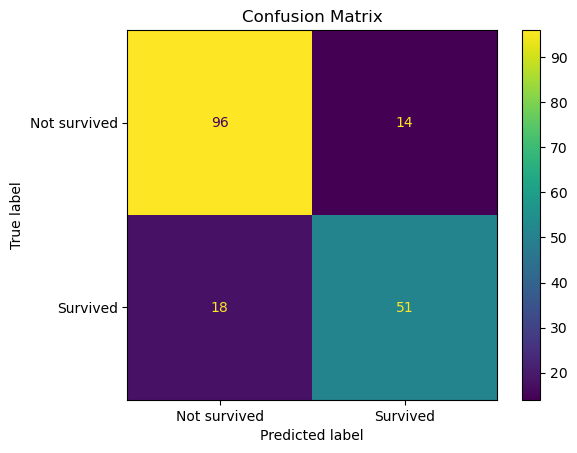

In [151]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not survived', 'Survived']
)

disp.plot()
plt.title('Confusion Matrix')
plt.show()

### Таблица конкретных ошибочных пассажиров

In [152]:
errors = df.loc[X_test.index].copy()

errors['y_true'] = y_test
errors['y_pred'] = y_pred
errors['probability'] = y_proba

errors = errors[errors['y_true'] != errors['y_pred']]
errors.sort_values('probability', ascending=False).head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Social_Rank,HasFamily,y_true,y_pred,probability
502,503,0,3,"O'Sullivan, Miss. Bridget Mary",female,NaN,0,0,330909,7.6292,NaN,Q,Miss,2,0,0,1,1.0
177,178,0,1,"Isham, Miss. Ann Elizabeth",female,50.0,0,0,PC 17595,28.7125,C49,C,Miss,2,0,0,1,1.0
404,405,0,3,"Oreskovic, Miss. Marija",female,20.0,0,0,315096,8.6625,NaN,S,Miss,2,0,0,1,0.8
415,416,0,3,"Meek, Mrs. Thomas (Annie Louise Rowley)",female,NaN,0,0,343095,8.0500,NaN,S,Mrs,3,0,0,1,0.8
767,768,0,3,"Mangan, Miss. Mary",female,30.5,0,0,364850,7.7500,NaN,Q,Miss,2,0,0,1,0.8
49,50,0,3,"Arnold-Franchi, Mrs. Josef (Josefine Franchi)",female,18.0,1,0,349237,17.8000,NaN,S,Mrs,3,1,0,1,0.8
246,247,0,3,"Lindahl, Miss. Agda Thorilda Viktoria",female,25.0,0,0,347071,7.7750,NaN,S,Miss,2,0,0,1,0.6
474,475,0,3,"Strandberg, Miss. Ida Sofia",female,22.0,0,0,7553,9.8375,NaN,S,Miss,2,0,0,1,0.6
741,742,0,1,"Cavendish, Mr. Tyrell William",male,36.0,1,0,19877,78.8500,C46,S,Mr,1,1,0,1,0.6
263,264,0,1,"Harrison, Mr. William",male,40.0,0,0,112059,0.0000,B94,S,Mr,1,0,0,1,0.6


### Ошибки по полу

In [153]:
pd.crosstab(
    errors['Sex'],
    errors['y_true'],
    normalize='index'
)

y_true,0,1
Sex,,
female,0.642857,0.357143
male,0.277778,0.722222


In [154]:
errors['Sex'].value_counts()

Sex
male      18
female    14
Name: count, dtype: int64

### Ошибки по классу

In [155]:
pd.crosstab(
    errors['Pclass'],
    errors['y_true']
)

y_true,0,1
Pclass,,
1,4,6
2,0,2
3,10,10


### Ошибки по возрасту

In [156]:
errors['AgeGroup'] = pd.cut(
    errors['Age'],
    bins=[0, 12, 18, 30, 50, 100],
    labels=['Child', 'Teen', 'Young adult', 'Adult', 'Senior']
)

errors['AgeGroup'].value_counts()

AgeGroup
Adult          14
Young adult     8
Teen            3
Child           1
Senior          1
Name: count, dtype: int64

### Самые уверенные ошибки модели

In [157]:
errors['confidence'] = np.where(
    errors['y_pred'] == 1,
    errors['probability'],
    1 - errors['probability']
)

errors.sort_values(
    'confidence',
    ascending=False
)[[
    'Name',
    'Sex',
    'Age',
    'Pclass',
    'y_true',
    'y_pred',
    'probability',
    'confidence'
]].head(10)

,Name,Sex,Age,Pclass,y_true,y_pred,probability,confidence
622,"Nakid, Mr. Sahid",male,20.0,3,1,0,0.0,1.0
828,"McCormack, Mr. Thomas Joseph",male,NaN,3,1,0,0.0,1.0
261,"Asplund, Master. Edvin Rojj Felix",male,3.0,3,1,0,0.0,1.0
177,"Isham, Miss. Ann Elizabeth",female,50.0,1,0,1,1.0,1.0
502,"O'Sullivan, Miss. Bridget Mary",female,NaN,3,0,1,1.0,1.0
127,"Madsen, Mr. Fridtjof Arne",male,24.0,3,1,0,0.0,1.0
673,"Wilhelms, Mr. Charles",male,31.0,2,1,0,0.0,1.0
17,"Williams, Mr. Charles Eugene",male,NaN,2,1,0,0.0,1.0
25,"Asplund, Mrs. Carl Oscar (Selma Augusta Emilia...",female,38.0,3,1,0,0.0,1.0
49,"Arnold-Franchi, Mrs. Josef (Josefine Franchi)",female,18.0,3,0,1,0.8,0.8


### Строим ROC-кривую

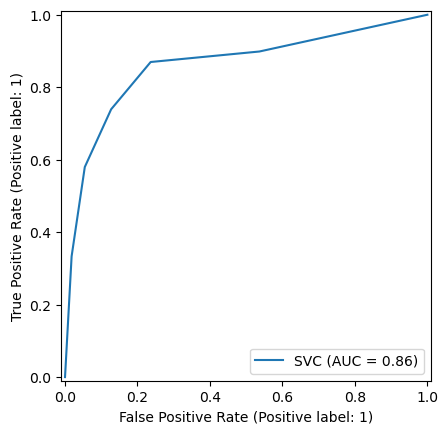

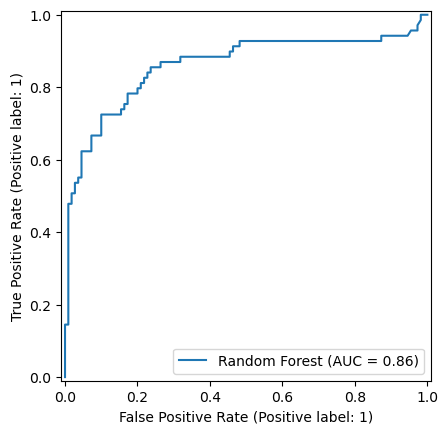

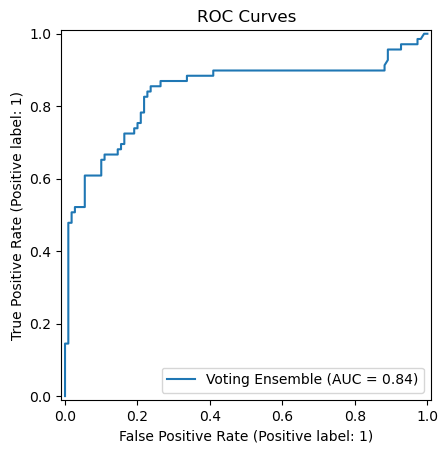

In [158]:
for name, model in best_models.items():
    model.fit(X_train, y_train)

    y_proba = model.predict_proba(X_test)[:, 1]

    RocCurveDisplay.from_predictions(
        y_test,
        y_proba,
        name=name
    )

plt.title('ROC Curves')
plt.show()

## Feature Importance

In [159]:
from sklearn.inspection import permutation_importance

svc = best_models['SVC']

svc.fit(X_train, y_train)

perm = permutation_importance(
    svc,
    X_test,
    y_test,
    scoring='roc_auc',
    n_repeats=10,
    random_state=21,
    n_jobs=-1
)

In [160]:
feature_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance': perm.importances_mean,
    'std': perm.importances_std
})

feature_importance = feature_importance.sort_values(
    'importance',
    ascending=False
)

feature_importance

,feature,importance,std
1,Sex,0.113076,0.029891
6,Social_Rank,0.092339,0.021340
0,Pclass,0.079242,0.020801
3,Fare,0.056976,0.013680
2,Age,0.045105,0.007466
7,HasFamily,0.034157,0.012885
4,Embarked,0.028478,0.010438
5,Title,0.000000,0.000000


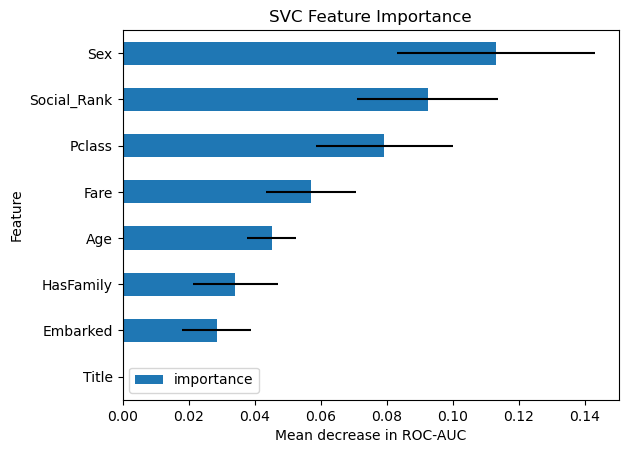

In [161]:
feature_importance.head(15).plot(
    x='feature',
    y='importance',
    kind='barh',
    xerr='std'
)

plt.gca().invert_yaxis()
plt.title('SVC Feature Importance')
plt.xlabel('Mean decrease in ROC-AUC')
plt.ylabel('Feature')
plt.show()

## ***Итоговый анализ:***

### 1. Лучшая модель по `ROC-AUC` - `SVC`, показатель - `0.874704`
### 2. Лучшая модель по `accuracy` - `Random Forest`, показатель - `0.849162`
### 3. Ансамбль не первысил метрику лучшей одиночной модели
### 4. Модель преимущественно ошибается в предсказаниях для объектов 3 класса возрастной категории 0-12 лет
### 5. Наиболее важный признак - `Sex`, топ 3 - `Pclass` и `Age`


In [163]:
test = pd.read_csv('../data/test.csv')
test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [164]:
test['Name'] = test['Name'].str.extract(
    ' ([A-Za-z]+)\.',
    expand=False
)

test['Social_Rank'] = (
    test['Name']
    .map(rank_map)
    .fillna(1)
    .astype(int)
)

test['HasFamily'] = test['SibSp'] + test['Parch']

test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Social_Rank,HasFamily
0,892,3,Mr,male,34.5,0,0,330911,7.8292,NaN,Q,1,0
1,893,3,Mrs,female,47.0,1,0,363272,7.0000,NaN,S,3,1
2,894,2,Mr,male,62.0,0,0,240276,9.6875,NaN,Q,1,0
3,895,3,Mr,male,27.0,0,0,315154,8.6625,NaN,S,1,0
4,896,3,Mrs,female,22.0,1,1,3101298,12.2875,NaN,S,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,Mr,male,NaN,0,0,A.5. 3236,8.0500,NaN,S,1,0
414,1306,1,Dona,female,39.0,0,0,PC 17758,108.9000,C105,C,1,0
415,1307,3,Mr,male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,1,0
416,1308,3,Mr,male,NaN,0,0,359309,8.0500,NaN,S,1,0


In [165]:
test_clean = test.drop(
    ['SibSp', 'Parch', 'Ticket'],
    axis=1
)

test_clean

,PassengerId,Pclass,Name,Sex,Age,Fare,Cabin,Embarked,Social_Rank,HasFamily
0,892,3,Mr,male,34.5,7.8292,NaN,Q,1,0
1,893,3,Mrs,female,47.0,7.0000,NaN,S,3,1
2,894,2,Mr,male,62.0,9.6875,NaN,Q,1,0
3,895,3,Mr,male,27.0,8.6625,NaN,S,1,0
4,896,3,Mrs,female,22.0,12.2875,NaN,S,3,2
...,...,...,...,...,...,...,...,...,...,...
413,1305,3,Mr,male,NaN,8.0500,NaN,S,1,0
414,1306,1,Dona,female,39.0,108.9000,C105,C,1,0
415,1307,3,Mr,male,38.5,7.2500,NaN,S,1,0
416,1308,3,Mr,male,NaN,8.0500,NaN,S,1,0


In [166]:
X_kaggle = test_clean.drop(
    ['PassengerId', 'Cabin', 'Name'],
    axis=1
)

X_kaggle

,Pclass,Sex,Age,Fare,Embarked,Social_Rank,HasFamily
0,3,male,34.5,7.8292,Q,1,0
1,3,female,47.0,7.0000,S,3,1
2,2,male,62.0,9.6875,Q,1,0
3,3,male,27.0,8.6625,S,1,0
4,3,female,22.0,12.2875,S,3,2
...,...,...,...,...,...,...,...
413,3,male,NaN,8.0500,S,1,0
414,1,female,39.0,108.9000,C,1,0
415,3,male,38.5,7.2500,S,1,0
416,3,male,NaN,8.0500,S,1,0


### Создадим несколько файлов с предсказаниями (для 3 моделей)

In [168]:
best_svc = best_models['SVC']
best_svc.fit(X_train, y_train)
svc_preds = best_svc.predict(X_kaggle)

submission_svc = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': svc_preds
})

submission_svc

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,0
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [169]:
best_rf = best_models['Random Forest']
best_rf.fit(X_train, y_train)
rf_preds = best_rf.predict(X_kaggle)

submission_rf = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': rf_preds
})

submission_rf

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [170]:
best_vot = best_models['Voting Ensemble']
best_vot.fit(X_train, y_train)
vot_preds = best_vot.predict(X_kaggle)

submission_vot = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': vot_preds
})

submission_vot

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


### Сохраняем `submissions`

In [172]:
submission_svc.to_csv(
    '../submissions/submission_svc.csv',
    index=False
)

submission_rf.to_csv(
    '../submissions/submission_rf.csv',
    index=False
)

submission_vot.to_csv(
    '../submissions/submission_vot.csv',
    index=False
)

# Итоговый `score`:

### 1. `Random Forest` = 0.77511
### 2. `SVC` = 0.76794
### 3. `Voting Classifier` = 0.76555